# Kalshi Series Inspection

This notebook loads `raw_series` from the Kalshi SQLite database and reproduces the current filtering logic from `kalshi_export/kalshi_registry/series_selection.py`.

It is designed as the series-level inspection notebook for the benchmark paper. Figures are saved into `artefacts/kalshi_plots`.


In [1]:
from __future__ import annotations

import sqlite3
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_colwidth", None)


In [2]:
def find_repo_root(start: Path) -> Path:
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / "kalshi_export").exists() and (candidate / "db").exists():
            return candidate
    raise RuntimeError("Could not locate repository root from current working directory")


REPO_ROOT = find_repo_root(Path.cwd())
KALSHI_EXPORT_ROOT = REPO_ROOT / "kalshi_export"
DB_PATH = REPO_ROOT / "db" / "kalshi_probability_dataset.sqlite"
PLOTS_DIR = REPO_ROOT / "artefacts" / "kalshi_plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

for path in (REPO_ROOT, KALSHI_EXPORT_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

print(f"REPO_ROOT={REPO_ROOT}")
print(f"KALSHI_EXPORT_ROOT={KALSHI_EXPORT_ROOT}")
print(f"DB_PATH={DB_PATH}")
print(f"PLOTS_DIR={PLOTS_DIR}")


def save_plot(name: str) -> Path:
    path = PLOTS_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    print(path)
    return path


REPO_ROOT=/Users/sneddy/research/polymarket_research
KALSHI_EXPORT_ROOT=/Users/sneddy/research/polymarket_research/kalshi_export
DB_PATH=/Users/sneddy/research/polymarket_research/db/kalshi_probability_dataset.sqlite
PLOTS_DIR=/Users/sneddy/research/polymarket_research/artefacts/kalshi_plots


In [3]:
from kalshi_registry.series_selection import (
    ALLOWED_CATEGORIES,
    DENIED_FREQUENCIES,
    DENIED_TITLE_PATTERNS,
    _matches_any,
)

sorted(ALLOWED_CATEGORIES)


['Companies',
 'Economics',
 'Elections',
 'Entertainment',
 'Financials',
 'Health',
 'Politics',
 'Science and Technology',
 'Social',
 'World']

In [4]:
with sqlite3.connect(DB_PATH) as conn:
    raw_series = pd.read_sql_query("SELECT * FROM raw_series", conn)

print(f"raw_series={raw_series.shape}")
raw_series.head(3)


raw_series=(9721, 13)


,series_ticker,title,subtitle,category,tags_json,frequency,status,created_at,updated_at,close_time,settlement_time,raw_payload_json,synced_at_utc
0,KXGRAMBARS,Best American Roots Song,None,Entertainment,"[""Awards""]",one_off,None,None,2026-02-26T08:50:31.901806Z,None,None,"{""additional_prohibitions"": [""Persons who are employed by any of the Source Agencies are not permitted to trade on the Contract."", ""Persons who hold any material, non-public information on the Underlying are not permitted to trade on the Contract.""], ""category"": ""Entertainment"", ""contract_terms_url"": ""https://kalshi-public-docs.s3.amazonaws.com/contract_terms/GRAMMY.pdf"", ""contract_url"": ""https://kalshi-public-docs.s3.us-east-1.amazonaws.com/regulatory/product-certifications/GRAMMY.pdf"", ""fee_multiplier"": 1, ""fee_type"": ""quadratic"", ""frequency"": ""one_off"", ""last_updated_ts"": ""2026-02-26T08:50:31.901806Z"", ""settlement_sources"": [{""name"": ""Recording Academy"", ""url"": ""https://www.grammy.com/""}], ""tags"": [""Awards""], ""ticker"": ""KXGRAMBARS"", ""title"": ""Best American Roots Song""}",2026-04-17T08:34:17Z
1,XCEOCHANGE,Linda Yaccarino leaves X,None,Companies,"[""CEOs"", ""Elon Musk""]",custom,None,None,2026-02-26T08:50:31.901806Z,None,None,"{""additional_prohibitions"": [""Persons who are employed by any of the Source Agencies are not permitted to trade on the Contract."", ""Persons who hold any material, non-public information on the Underlying are not permitted to trade on the Contract.""], ""category"": ""Companies"", ""contract_terms_url"": ""https://kalshi-public-docs.s3.amazonaws.com/contract_terms/XCEOCHANGE.pdf"", ""contract_url"": ""https://kalshi-public-docs.s3.us-east-1.amazonaws.com/regulatory/product-certifications/XCEOCHANGE.pdf"", ""fee_multiplier"": 1, ""fee_type"": ""quadratic"", ""frequency"": ""custom"", ""last_updated_ts"": ""2026-02-26T08:50:31.901806Z"", ""settlement_sources"": [{""name"": ""Bloomberg"", ""url"": ""https://www.bloomberg.com/""}, {""name"": ""X"", ""url"": ""https://twitter.com/home""}], ""tags"": [""CEOs"", ""Elon Musk""], ""ticker"": ""XCEOCHANGE"", ""title"": ""Linda Yaccarino leaves X""}",2026-04-17T08:34:17Z
2,KXTOPSEASONPV,Top media by platform?,None,Entertainment,"[""Movies"", ""Television""]",one_off,None,None,2026-04-16T21:43:10.006375Z,None,None,"{""additional_prohibitions"": [""Persons who are employed by any of the Source Agencies are not permitted to trade on the Contract."", ""Persons who hold any material, non-public information on the Underlying are not permitted to trade on the Contract.""], ""category"": ""Entertainment"", ""contract_terms_url"": ""https://kalshi-public-docs.s3.amazonaws.com/contract_terms/RANKLISTLUMINATECHART.pdf"", ""contract_url"": ""https://kalshi-public-docs.s3.us-east-1.amazonaws.com/regulatory/product-certifications/RANKLISTLUMINATECHART.pdf"", ""fee_multiplier"": 1, ""fee_type"": ""quadratic"", ""frequency"": ""one_off"", ""last_updated_ts"": ""2026-04-16T21:43:10.006375Z"", ""settlement_sources"": [{""name"": ""Luminate"", ""url"": ""https://luminatedata.com/""}], ""tags"": [""Movies"", ""Television""], ""ticker"": ""KXTOPSEASONPV"", ""title"": ""Top media by platform?""}",2026-04-17T08:34:17Z


## Reproduce current `series_selection.py` logic

The masks below intentionally match the current script as implemented.


In [8]:
series_df = raw_series.copy()
series_df["category_norm"] = series_df["category"].fillna("").astype(str).str.strip()
series_df["frequency_norm"] = series_df["frequency"].fillna("").astype(str).str.strip().str.lower()
series_df["title_norm"] = series_df["title"].fillna("").astype(str)
series_df["subtitle_norm"] = series_df["subtitle"].fillna("").astype(str)
series_df["ticker_norm"] = series_df["series_ticker"].fillna("").astype(str)
series_df["tags_norm"] = series_df["tags_json"].fillna("").astype(str)
series_df["text_blob"] = series_df["title_norm"] + " " + series_df["subtitle_norm"] + " " + series_df["tags_norm"]
series_df.head(2)


,series_ticker,title,subtitle,category,tags_json,frequency,status,created_at,updated_at,close_time,settlement_time,raw_payload_json,synced_at_utc,category_norm,frequency_norm,title_norm,subtitle_norm,ticker_norm,tags_norm,text_blob
0,KXXRPMAXM,XRP max monthly,None,Crypto,NaN,custom,None,None,2026-02-26T08:50:31.901806Z,None,None,"{""additional_prohibitions"": [""Persons who are employed by any of the Source Agencies are not permitted to trade on the Contract."", ""Persons who hold any material, non-public information on the Underlying are not permitted to trade on the Contract.""], ""category"": ""Crypto"", ""contract_terms_url"": ""https://kalshi-public-docs.s3.amazonaws.com/contract_terms/RIPPLEMINMAX.pdf"", ""contract_url"": ""https://kalshi-public-docs.s3.us-east-1.amazonaws.com/regulatory/product-certifications/RIPPLEMINMAX.pdf"", ""fee_multiplier"": 1, ""fee_type"": ""quadratic"", ""frequency"": ""custom"", ""last_updated_ts"": ""2026-02-26T08:50:31.901806Z"", ""settlement_sources"": [{""name"": ""CF Benchmarks"", ""url"": ""https://www.cfbenchmarks.com/""}], ""tags"": null, ""ticker"": ""KXXRPMAXM"", ""title"": ""XRP max monthly""}",2026-04-13T09:16:08Z,Crypto,custom,XRP max monthly,,KXXRPMAXM,,XRP max monthly
1,KXCBDECISIONKOREA,Bank Of KOREA policy interest rate decision,None,Economics,"[""Global Central Banks""]",custom,None,None,2026-03-30T20:44:48.903491Z,None,None,"{""additional_prohibitions"": [""Persons who are employed by any of the Source Agencies are not permitted to trade on the Contract."", ""Persons who hold any material, non-public information on the Underlying are not permitted to trade on the Contract.""], ""category"": ""Economics"", ""contract_terms_url"": ""https://kalshi-public-docs.s3.amazonaws.com/contract_terms/CBDECISION.pdf"", ""contract_url"": ""https://kalshi-public-docs.s3.us-east-1.amazonaws.com/regulatory/product-certifications/CBDECISION.pdf"", ""fee_multiplier"": 1, ""fee_type"": ""quadratic"", ""frequency"": ""custom"", ""last_updated_ts"": ""2026-03-30T20:44:48.903491Z"", ""settlement_sources"": [{""name"": ""ABC"", ""url"": ""https://abcnews.go.com/""}, {""name"": ""Associated Press"", ""url"": ""https://apnews.com""}, {""name"": ""Axios"", ""url"": ""https://www.axios.com""}, {""name"": ""BBC"", ""url"": ""https://www.bbc.co.uk""}, {""name"": ""Bloomberg News"", ""url"": ""https://www.bloomberg.com/news""}, {""name"": ""Bloomberg Terminal"", ""url"": ""https://kalshi.com/""}, {""name"": ""CBS"", ""url"": ""https://www.cbsnews.com/""}, {""name"": ""central bank"", ""url"": ""https://kalshi.com/""}, {""name"": ""CNN"", ""url"": ""https://www.cnn.com/""}, {""name"": ""Federal Reserve Economic Data"", ""url"": ""https://kalshi.com/""}, {""name"": ""Financial Times"", ""url"": ""https://www.ft.com""}, {""name"": ""Fox News"", ""url"": ""https://www.foxnews.com""}, {""name"": ""in hierarchical order"", ""url"": ""https://kalshi.com/""}, {""name"": ""MarketWatch"", ""url"": ""https://kalshi.com/""}, {""name"": ""MSNBC"", ""url"": ""https://www.msnbc.com""}, {""name"": ""NBC"", ""url"": ""https://www.nbcnews.com/""}, {""name"": ""Politico"", ""url"": ""https://www.politico.com""}, {""name"": ""Reuters"", ""url"": ""https://www.reuters.com/""}, {""name"": ""Semafor"", ""url"": ""https://semafor.com""}, {""name"": ""The Information"", ""url"": ""https://www.theinformation.com/""}, {""name"": ""The New York Times"", ""url"": ""https://www.nytimes.com""}, {""name"": ""The Wall Street Journal"", ""url"": ""https://www.wsj.com/""}, {""name"": ""The Washington Post"", ""url"": ""https://www.washingtonpost.com/""}], ""tags"": [""Global Central Banks""], ""ticker"": ""KXCBDECISIONKOREA"", ""title"": ""Bank Of KOREA policy interest rate decision""}",2026-04-13T09:16:08Z,Economics,custom,Bank Of KOREA policy interest rate decision,,KXCBDECISIONKOREA,"[""Global Central Banks""]","Bank Of KOREA policy interest rate decision [""Global Central Banks""]"


In [5]:
series_df = raw_series.copy()
series_df["category_norm"] = series_df["category"].fillna("").astype(str).str.strip()
series_df["frequency_norm"] = series_df["frequency"].fillna("").astype(str).str.strip().str.lower()
series_df["title_norm"] = series_df["title"].fillna("").astype(str)
series_df["subtitle_norm"] = series_df["subtitle"].fillna("").astype(str)
series_df["ticker_norm"] = series_df["series_ticker"].fillna("").astype(str)
series_df["tags_norm"] = series_df["tags_json"].fillna("").astype(str)
series_df["text_blob"] = series_df["title_norm"] + " " + series_df["subtitle_norm"] + " " + series_df["tags_norm"]

series_df["pass_frequency"] = ~series_df["frequency_norm"].isin(DENIED_FREQUENCIES)
series_df["pass_category"] = series_df["category_norm"].isin(ALLOWED_CATEGORIES)
series_df["denied_by_title"] = series_df["text_blob"].map(lambda text: _matches_any(DENIED_TITLE_PATTERNS, text))

series_df["after_frequency"] = series_df["pass_frequency"]
series_df["after_category"] = series_df["after_frequency"] & series_df["pass_category"]
series_df["selected_by_script"] = series_df["after_category"] & ~series_df["denied_by_title"]

selected_df = series_df.loc[series_df["selected_by_script"]].copy()
selected_df[["series_ticker", "title", "category_norm", "frequency", "status"]].head(20)


,series_ticker,title,category_norm,frequency,status
0,KXGRAMBARS,Best American Roots Song,Entertainment,one_off,None
1,XCEOCHANGE,Linda Yaccarino leaves X,Companies,custom,None
2,KXTOPSEASONPV,Top media by platform?,Entertainment,one_off,None
3,KXNORWAYPM,Norway PM,Politics,custom,None
4,KXSONGRELEASESTYLES,WHEN WILL HARRY STYLES RELEASE A NEW SONG,Entertainment,one_off,None
7,GOVPARTYNE,Nebraska governor,Elections,one_off,None
8,VULTURES,New Kanye album release date,Entertainment,custom,None
9,KXSENATEPAD,Democratic nominee for Senate in Pennsylvania?,Elections,one_off,None
10,KXCBDECISIONEU,EU CENTRAL BANK POLICY INTEREST RATE,Economics,custom,None
11,KXSPR,SPRMAX,Economics,one_off,None


In [6]:
filter_counts = pd.DataFrame(
    {
        "stage": [
            "all raw_series",
            "after frequency filter",
            "after category filter",
            "after title deny",
        ],
        "rows": [
            len(series_df),
            int(series_df["after_frequency"].sum()),
            int(series_df["after_category"].sum()),
            int(series_df["selected_by_script"].sum()),
        ],
    }
)
filter_counts["pct_of_raw"] = (100.0 * filter_counts["rows"] / max(len(series_df), 1)).round(2)
filter_counts["dropped_this_step"] = filter_counts["rows"].shift(1, fill_value=filter_counts.loc[0, "rows"]) - filter_counts["rows"]
filter_counts


,stage,rows,pct_of_raw,dropped_this_step
0,all raw_series,9721,100.00,0
1,after frequency filter,9487,97.59,234
2,after category filter,6905,71.03,2582
3,after title deny,6239,64.18,666


/Users/sneddy/research/polymarket_research/artefacts/kalshi_plots/kalshi_series_selection_funnel.png


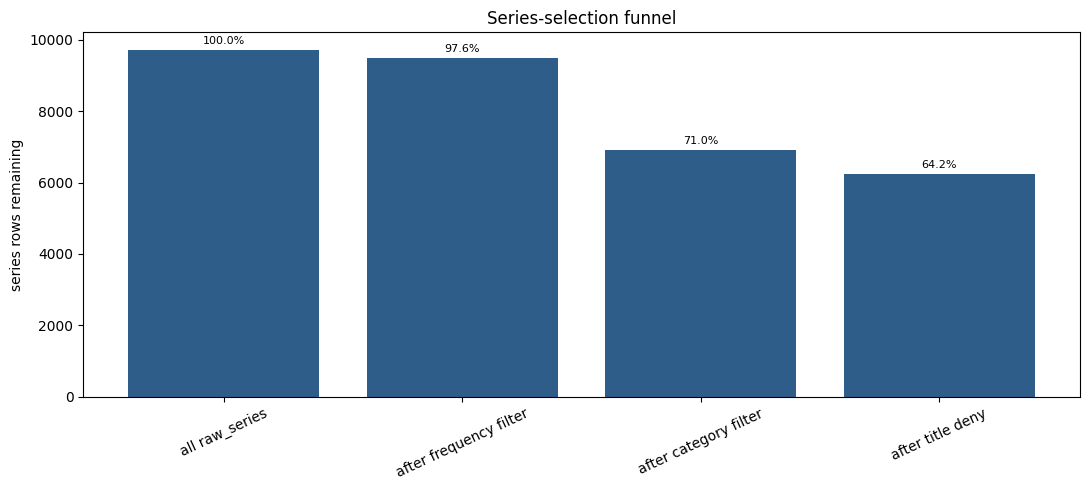

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(filter_counts["stage"], filter_counts["rows"], color="#2f5d8a")
ax.set_title("Series-selection funnel")
ax.set_ylabel("series rows remaining")
ax.tick_params(axis="x", rotation=25)

for bar, pct in zip(bars, filter_counts["pct_of_raw"]):
    height = bar.get_height()
    ax.annotate(
        f"{pct:.1f}%",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8,
    )

save_plot("kalshi_series_selection_funnel.png")
plt.show()


In [8]:
category_counts = (
    series_df.groupby("category_norm", dropna=False)
    .size()
    .reset_index(name="series_count")
    .sort_values("series_count", ascending=False)
)
category_counts.head(20)


,category_norm,series_count
8,Entertainment,2358
13,Politics,1827
16,Sports,1739
7,Elections,1262
5,Economics,509
3,Companies,351
12,Mentions,336
1,Climate and Weather,269
4,Crypto,225
14,Science and Technology,203


/Users/sneddy/research/polymarket_research/artefacts/kalshi_plots/kalshi_raw_series_top_categories.png


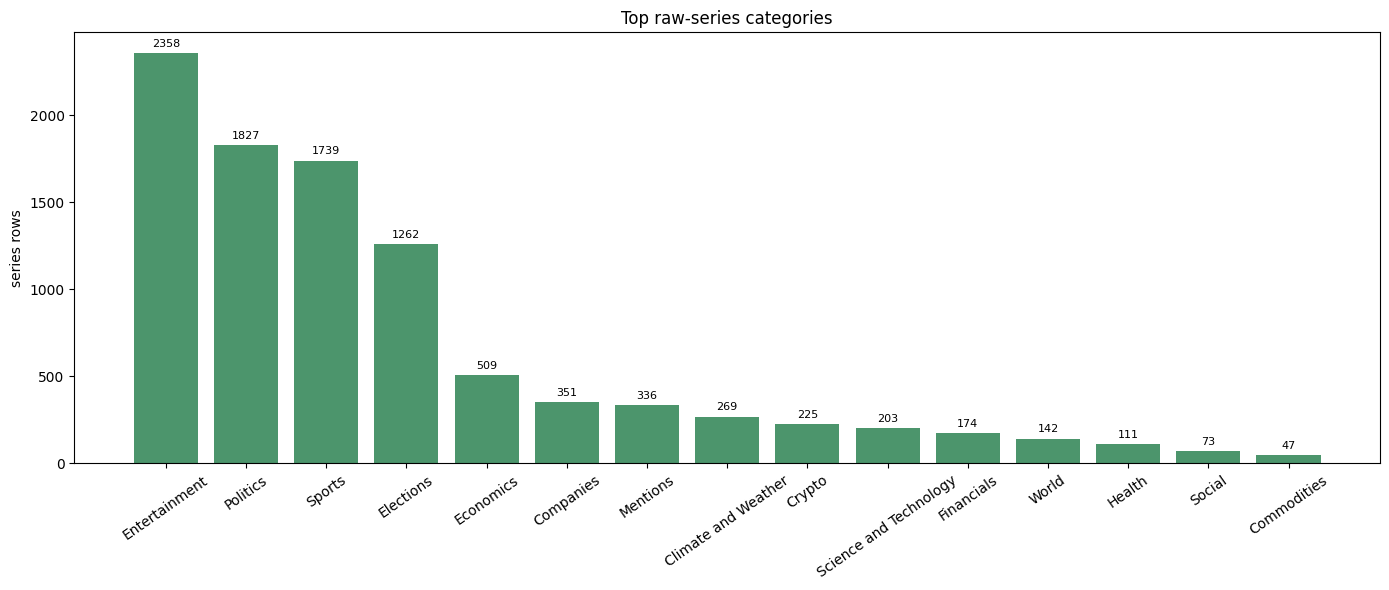

In [9]:
plot_categories = category_counts.head(15).copy()
fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(plot_categories["category_norm"], plot_categories["series_count"], color="#4c956c")
ax.set_title("Top raw-series categories")
ax.set_ylabel("series rows")
ax.tick_params(axis="x", rotation=35)

for bar in bars:
    height = int(bar.get_height())
    ax.annotate(
        f"{height}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8,
    )

save_plot("kalshi_raw_series_top_categories.png")
plt.show()


## Category comparison before and after selection


In [10]:
raw_series_category_counts = (
    series_df.groupby("category_norm", dropna=False)
    .size()
    .reset_index(name="raw_series_rows")
)

selected_series_category_counts = (
    selected_df.groupby("category_norm", dropna=False)
    .size()
    .reset_index(name="selected_series_rows")
)

category_compare = (
    raw_series_category_counts.merge(selected_series_category_counts, on="category_norm", how="outer")
    .fillna(0)
)
category_compare[["raw_series_rows", "selected_series_rows"]] = category_compare[["raw_series_rows", "selected_series_rows"]].astype(int)
category_compare["selection_rate_pct"] = (
    100.0 * category_compare["selected_series_rows"] / category_compare["raw_series_rows"].replace({0: np.nan})
).round(2)
category_compare = category_compare.sort_values("raw_series_rows", ascending=False)
category_compare.head(20)


,category_norm,raw_series_rows,selected_series_rows,selection_rate_pct
8,Entertainment,2358,1779,75.45
13,Politics,1827,1804,98.74
16,Sports,1739,0,0.00
7,Elections,1262,1261,99.92
5,Economics,509,447,87.82
3,Companies,351,351,100.00
12,Mentions,336,0,0.00
1,Climate and Weather,269,0,0.00
4,Crypto,225,0,0.00
14,Science and Technology,203,195,96.06


/Users/sneddy/research/polymarket_research/artefacts/kalshi_plots/kalshi_series_categories_before_after.png


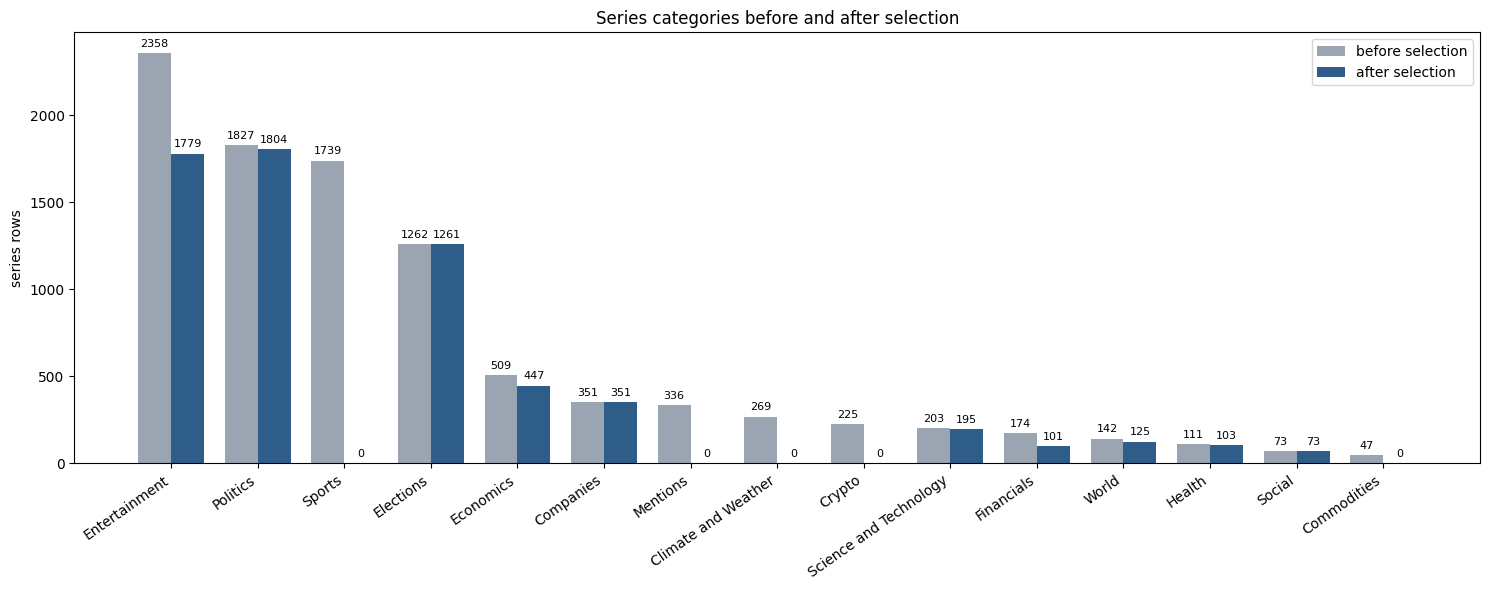

In [11]:
plot_categories = category_compare.head(15).copy()
x = np.arange(len(plot_categories))
width = 0.38

fig, ax = plt.subplots(figsize=(15, 6))
bars1 = ax.bar(x - width / 2, plot_categories["raw_series_rows"], width, label="before selection", color="#9aa5b1")
bars2 = ax.bar(x + width / 2, plot_categories["selected_series_rows"], width, label="after selection", color="#2f5d8a")
ax.set_title("Series categories before and after selection")
ax.set_ylabel("series rows")
ax.set_xticks(x)
ax.set_xticklabels(plot_categories["category_norm"], rotation=35, ha="right")
ax.legend()

for bars in (bars1, bars2):
    for bar in bars:
        height = int(bar.get_height())
        ax.annotate(
            f"{height}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8,
        )

save_plot("kalshi_series_categories_before_after.png")
plt.show()


/Users/sneddy/research/polymarket_research/artefacts/kalshi_plots/kalshi_series_selection_rate_by_category.png


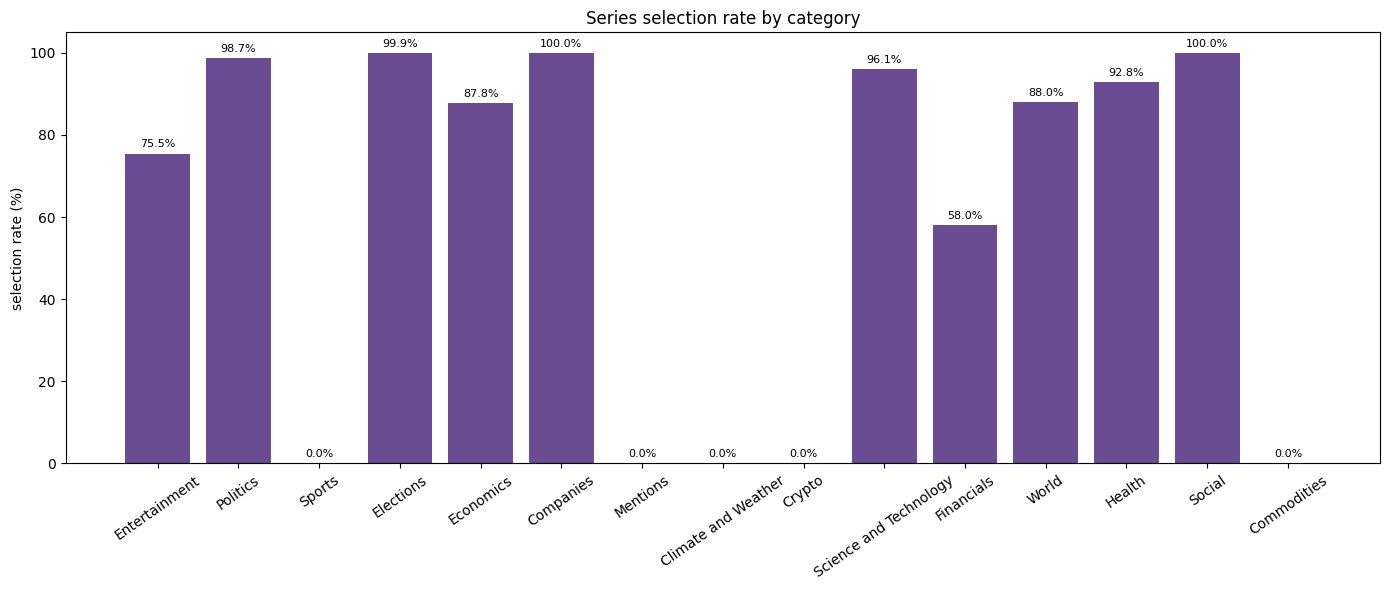

In [12]:
plot_rate = category_compare.head(15).copy()
fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(plot_rate["category_norm"], plot_rate["selection_rate_pct"].fillna(0), color="#6a4c93")
ax.set_title("Series selection rate by category")
ax.set_ylabel("selection rate (%)")
ax.tick_params(axis="x", rotation=35)

for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f"{height:.1f}%",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8,
    )

save_plot("kalshi_series_selection_rate_by_category.png")
plt.show()


In [13]:
frequency_compare = (
    series_df.groupby(series_df["frequency"].fillna(""), dropna=False)
    .size()
    .reset_index(name="raw_series_rows")
    .rename(columns={"frequency": "frequency_norm"})
    .merge(
        selected_df.groupby(selected_df["frequency"].fillna(""), dropna=False)
        .size()
        .reset_index(name="selected_series_rows")
        .rename(columns={"frequency": "frequency_norm"}),
        on="frequency_norm",
        how="outer",
    )
    .fillna(0)
)
frequency_compare[["raw_series_rows", "selected_series_rows"]] = frequency_compare[["raw_series_rows", "selected_series_rows"]].astype(int)
frequency_compare = frequency_compare.sort_values("raw_series_rows", ascending=False)
frequency_compare


,frequency_norm,raw_series_rows,selected_series_rows
1,custom,3977,2421
6,one_off,3848,2978
0,annual,1225,608
5,monthly,261,140
2,daily,191,0
7,weekly,176,92
4,hourly,34,0
3,fifteen_min,9,0


In [14]:
raw_series.frequency.value_counts()

frequency
custom         3977
one_off        3848
annual         1225
monthly         261
daily           191
weekly          176
hourly           34
fifteen_min       9
Name: count, dtype: int64

/Users/sneddy/research/polymarket_research/artefacts/kalshi_plots/kalshi_series_frequency_before_after.png


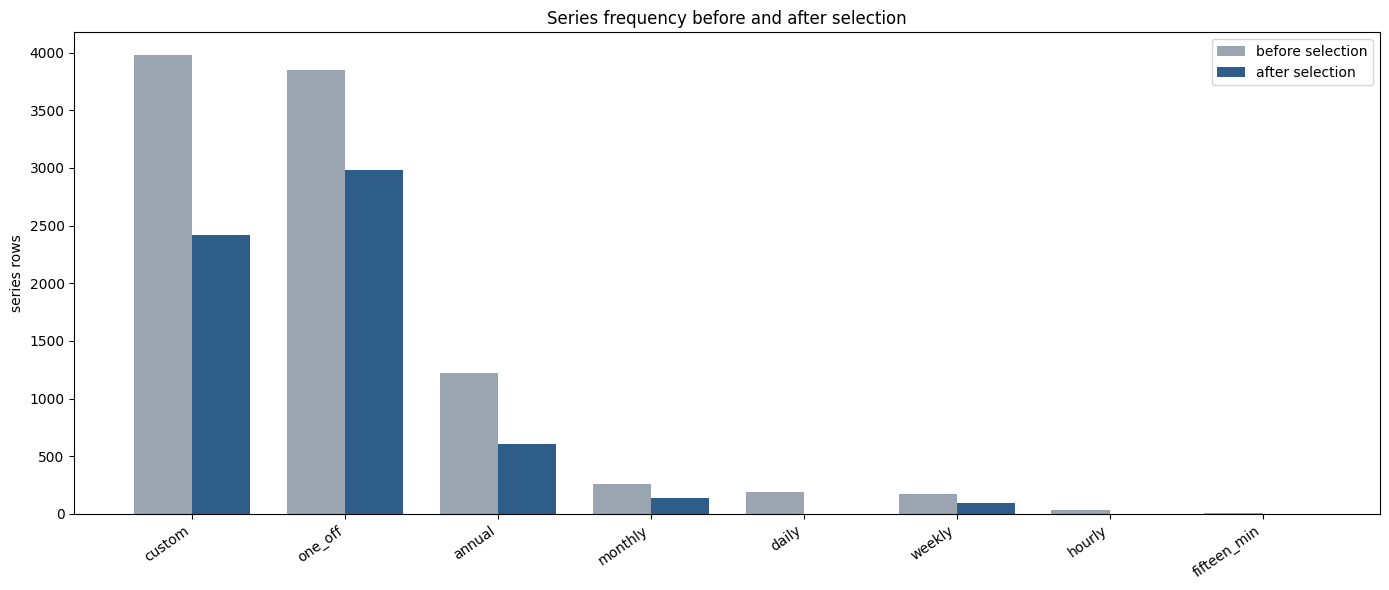

In [15]:
plot_frequency = frequency_compare.head(12).copy()
x = np.arange(len(plot_frequency))
width = 0.38

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width / 2, plot_frequency["raw_series_rows"], width, label="before selection", color="#9aa5b1")
ax.bar(x + width / 2, plot_frequency["selected_series_rows"], width, label="after selection", color="#2f5d8a")
ax.set_title("Series frequency before and after selection")
ax.set_ylabel("series rows")
ax.set_xticks(x)
ax.set_xticklabels(plot_frequency["frequency_norm"], rotation=35, ha="right")
ax.legend()
save_plot("kalshi_series_frequency_before_after.png")
plt.show()


In [16]:
deny_summary = pd.DataFrame(
    {
        "reason": [
            "frequency removed",
            "fails category allowlist",
            "denied by title patterns",
        ],
        "rows": [
            int((~series_df["pass_frequency"]).sum()),
            int((series_df["after_frequency"] & ~series_df["pass_category"]).sum()),
            int((series_df["after_category"] & series_df["denied_by_title"]).sum()),
        ],
    }
)
deny_summary


,reason,rows
0,frequency removed,234
1,fails category allowlist,2582
2,denied by title patterns,666


/Users/sneddy/research/polymarket_research/artefacts/kalshi_plots/kalshi_series_deny_rule_counts.png


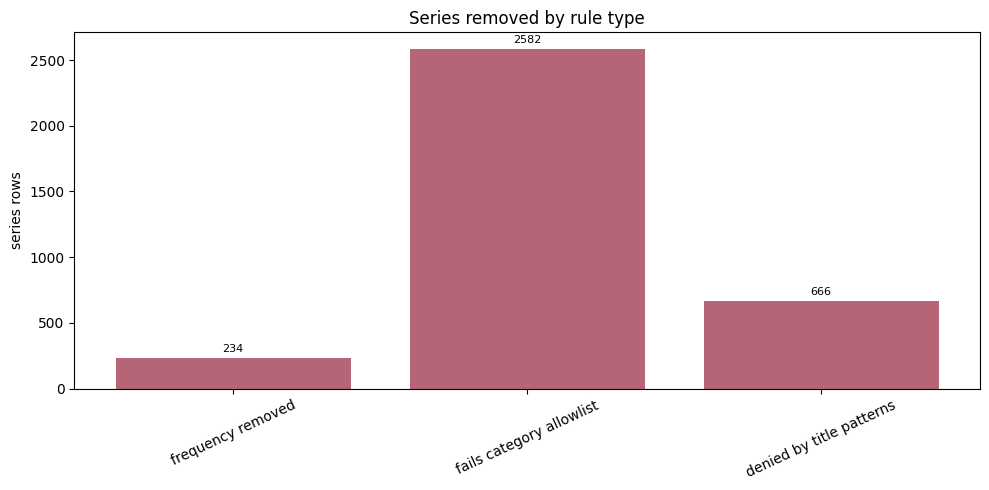

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(deny_summary["reason"], deny_summary["rows"], color="#b56576")
ax.set_title("Series removed by rule type")
ax.set_ylabel("series rows")
ax.tick_params(axis="x", rotation=25)

for bar in bars:
    height = int(bar.get_height())
    ax.annotate(
        f"{height}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8,
    )

save_plot("kalshi_series_deny_rule_counts.png")
plt.show()


## Sample series dropped at each stage

This cell samples the series that are removed by each stage of `series_selection` in order.


In [18]:
drop_samples = {
    "dropped_by_frequency": series_df.loc[
        ~series_df["pass_frequency"],
        ["series_ticker", "title", "category_norm", "frequency", "tags_norm"],
    ].sample(n=min(10, int((~series_df["pass_frequency"]).sum())), random_state=7) if int((~series_df["pass_frequency"]).sum()) else pd.DataFrame(),
    "dropped_by_category": series_df.loc[
        series_df["after_frequency"] & ~series_df["pass_category"],
        ["series_ticker", "title", "category_norm", "frequency", "tags_norm"],
    ].sample(n=min(10, int((series_df["after_frequency"] & ~series_df["pass_category"]).sum())), random_state=7) if int((series_df["after_frequency"] & ~series_df["pass_category"]).sum()) else pd.DataFrame(),
    "dropped_by_title_patterns": series_df.loc[
        series_df["after_category"] & series_df["denied_by_title"],
        ["series_ticker", "title", "category_norm", "frequency", "tags_norm"],
    ].sample(n=min(10, int((series_df["after_category"] & series_df["denied_by_title"]).sum())), random_state=7) if int((series_df["after_category"] & series_df["denied_by_title"]).sum()) else pd.DataFrame(),
}

for stage_name, sample_df in drop_samples.items():
    print(f"\n=== {stage_name} ===")
    display(sample_df)



=== dropped_by_frequency ===


,series_ticker,title,category_norm,frequency,tags_norm
6049,KXHYPE,Hype,Crypto,hourly,"[""HYPE""]"
3581,KXGBPUSDH,GBP/USD over/under,Financials,hourly,
3683,KXCOPPERD,Daily Copper,Commodities,daily,"[""Metals""]"
8447,KXCS2MAP,Counter-Strike 2 Map Winner,Sports,daily,"[""Esports""]"
261,KXNETFLIXMOVIERANKD,Top Netflix movie daily,Entertainment,daily,
3684,KXHIGHTPHX,Phoenix High Temperature Daily,Climate and Weather,daily,"[""Daily temperature""]"
4495,KXRIPPLED,Ripple price Above/below,Crypto,daily,
448,ETH,Ethereum range,Crypto,daily,"[""ETH""]"
6217,FLIGHTLAX,Los Angeles International Airport total delays and cancellations,Transportation,daily,"[""Airlines & aviation""]"
3601,KXSHIBA,Shiba range,Crypto,daily,



=== dropped_by_category ===


,series_ticker,title,category_norm,frequency,tags_norm
871,KXOLEMISSATTENDANCE,Ole Miss Attendance Record,Sports,custom,"[""Football""]"
7674,KXF1SPRINTTOP5,F1 Sprint Race Top 5 Finishers,Sports,custom,"[""Motorsport""]"
5408,KXCOACHOUTNBA,NBA Coach Out,Sports,custom,
2739,KXEMERGENCYWIL,Natural disaster hits Wilmington,Climate and Weather,custom,"[""Hurricanes""]"
3201,KXWOBOB,Winter Olympics Bobsled,Sports,custom,"[""Olympics""]"
4847,KXSOL26500,Sol above 500 in 2026,Crypto,one_off,"[""SOL""]"
8170,KXCHESSWORLDCHAMPION,World Chess Champion,Sports,custom,"[""Chess""]"
5751,KXSURVIVORMENTION,Survivor Mention,Mentions,one_off,"[""Politicians""]"
2251,KXDJTDAS,What will Trump say in his address to the Digital Asset Summit?,Mentions,one_off,
6810,KXPUBGGC,PUBG Global Championship 2025,Sports,one_off,"[""Esports""]"



=== dropped_by_title_patterns ===


,series_ticker,title,category_norm,frequency,tags_norm
4213,KXRTXPRO6000W,RTX PRO 6000 Weekly Price,Science and Technology,weekly,"[""Energy"", ""AI""]"
5630,KXRTTWISTERS,Twisters Rotten Tomatoes score,Entertainment,custom,"[""Movies"", ""Rotten Tomatoes""]"
9719,KXTOPSHOWPV,What will be the top show by hours watched on platform this week?,Entertainment,one_off,"[""Movies"", ""Television""]"
1343,KXSPOTIFYSONGCITYMIAMIW,Top song Miami,Entertainment,custom,"[""Music"", ""Music charts""]"
7228,KXRTNOBODY2,NOBODY 2 Rotten Tomatoes score,Entertainment,custom,"[""Movies"", ""Rotten Tomatoes""]"
2807,MCZELDAEOW,ZELDA EOW Metacritic scores,Entertainment,custom,"[""Video games""]"
8299,KXSPOTIFYSONGSROMEO,How many total streams will Romeo get?,Entertainment,custom,"[""Music""]"
8029,KXSTOCKX11GAMMABLUE,"Will the average sales price of the XXX on StockX, be above XXX 7 days after release?",Entertainment,one_off,"[""StockX""]"
8802,KXRTTHEWOMANINTHEYARD,THE WOMAN IN THE YARD Rotten Tomatoes score,Entertainment,custom,"[""Movies"", ""Rotten Tomatoes""]"
1682,KXRTMEGALOPOLIS,Megalopolis Rotten Tomatoes score,Entertainment,one_off,"[""Movies"", ""Rotten Tomatoes""]"


In [19]:
series_df.loc[series_df["after_category"] & series_df["denied_by_title"],
        ["series_ticker", "title", "category_norm", "frequency", "tags_norm"],
    ].sample(20).title

4655    HOW MANY STREAMS WILL BLIND FOLD BY CHRIS BROWN GET ON SPOTIFY
9342        Taylor swift holds top ten spots on the Billboard Hot 100?
4290                                             Rotten Tomatoes score
3068                                    POUR ME A DRINK Billboard Peak
1320                              Donkey Kong Bananza metacritic score
7322                                                   Top song length
9577                                     Tate Mcrae total stream count
4031                       What will Trump's approval rating be today?
7116                                          Revelation total streams
8218                       France GDP Growth Rate YoY Prel (quarterly)
2112                                   FBC: Firebreak metacritic score
2853        How many straight weeks will the life of a show girl be #1
5428                                    Clair Obscur Metacritic scores
335                                             Natural gas yearly low
3227  

In [ ]:
selected_df[["series_ticker", "title", "category_norm", "frequency"]].head(20)


,series_ticker,title,category_norm,frequency,tags_norm
191,KXWINDSORWEST,Windsor West,Politics,one_off,"[""Foreign Elections""]"
385,KXTEMPMON,Global monthly temperature average,Climate and Weather,monthly,
398,KXHIGHTEMPDEN,High temperature denver,Climate and Weather,custom,
585,KXBTCD-B,Bitcoin on election day,Crypto,custom,"[""BTC""]"
753,ETHD,Ethereum price Above/below,Crypto,daily,"[""ETH""]"
1047,KXETHD,Ethereum price Above/below,Crypto,hourly,"[""Hourly"", ""ETH""]"
1310,MICHTEMP,Lake Michigan surface water temperature,Climate and Weather,monthly,
1459,KXDOGED,Dogecoin price Above/below,Crypto,hourly,"[""Hourly"", ""DOGE""]"
1547,KXMAXTEMP100,Max temp 100,Climate and Weather,custom,
2134,KXDOGEDIV,Doge Dividend,Politics,one_off,


In [25]:
selected_df[selected_df["title"].str.contains("viewership", case=False, na=False)].title


393           Oscars viewership
3679              SB viewership
7527    Inauguration viewership
Name: title, dtype: str